## Assignment 08 :: Clustering and Dimensionality Reduction

In [340]:
#importing required Libraries

import numpy as np
import pandas as pd


In [362]:
#importing dataset
from sklearn.datasets import load_iris

#Load the dataset
iris = load_iris()

#convert into dataframe
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

#Display first few rows
print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [363]:
print(df.columns)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')


In [364]:
df.shape

(150, 5)

In [365]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [366]:
#find  missing values
print("\n\n\n #Missing values:\n")
print(df.isnull().sum(), "\n\n")




 #Missing values:

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64 




In [367]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1


In [368]:
#To view the duplicate column
duplicates = df[df.duplicated()]

print(duplicates)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
142                5.8               2.7                5.1               1.9   

       species  
142  virginica  


In [369]:
#need to drop the duplicat values

df.drop_duplicates(inplace=True)

In [370]:

print("Duplicate values:", df.duplicated().sum(), "\n\n\n")

Duplicate values: 0 





In [371]:
print(df.columns.tolist())

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']


In [372]:
df.shape

(149, 5)

In [373]:
print(id(df))


1554185514784


In [374]:
# Features
x = df.drop("species", axis=1)

# Target
y = df["species"]

In [375]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  149 non-null    float64
 1   sepal width (cm)   149 non-null    float64
 2   petal length (cm)  149 non-null    float64
 3   petal width (cm)   149 non-null    float64
dtypes: float64(4)
memory usage: 5.8 KB


In [376]:
x.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631
std,0.830851,0.436342,1.767791,0.762622
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [377]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  149 non-null    float64
 1   sepal width (cm)   149 non-null    float64
 2   petal length (cm)  149 non-null    float64
 3   petal width (cm)   149 non-null    float64
dtypes: float64(4)
memory usage: 5.8 KB


In [378]:
#Feature scaling

#Using standard scsaler, importing the library.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [379]:
##CLustering

#K-Means Clustering

it is an unsupervised learning algorithm that groups similar data points into K clusters 
based on their distance from cluster centroids. Chooses K random centroids,Assigns every flower
to the nearest centroid,Calculates a new centroid for each cluster,Repeats until the centroids 
stop moving

In [380]:
#K-Means

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(x_scaled)


C:\Users\athul\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


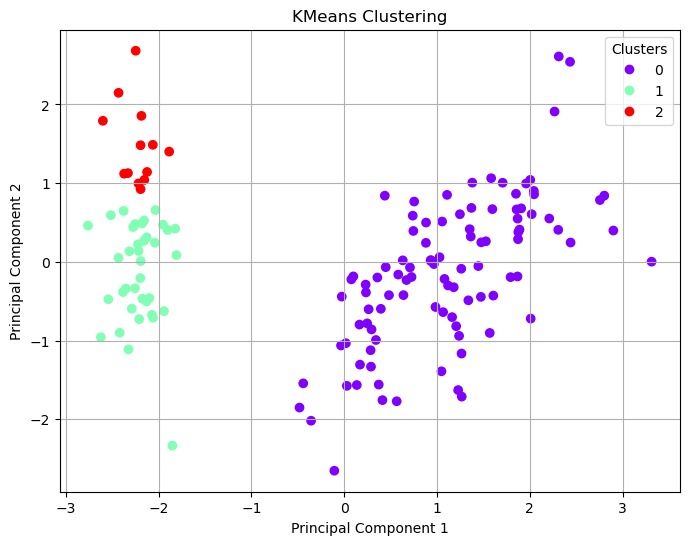

In [381]:
#Visualisation K-Means Clustering

#import Principal Component Analysis class from the scikit-learn library, which is used for 
#dimensionality reduction and data visualization.
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D#another library in matplotlib
import seaborn as sns

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=clusters,
    cmap='rainbow'
)

plt.title("KMeans Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

#Create legend
legend1 = plt.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

plt.grid(True)
plt.show()

In [324]:
#report


K-Means is suitable for the Iris dataset because the flowers naturally form groups based on their 
measurements. The dataset contains numerical features with relatively well-separated clusters, 
making centroid-based clustering effective. also Due to overlapping feature values cannot be identified with 100% certainty for the legend therefore visualizing per clusters.


#Hierarchical clustering


Hierarchical Clustering builds a tree-like structure of clusters called a dendrogram without 
requiring you to pre-specify the number of groups, operating through either a bottom-up 
(agglomerative) approach where each data point starts as its own cluster and pairs are merged 
iteratively, or a top-down (divisive) approach where all points start in one cluster and are 
split recursively. In the common agglomerative method, the algorithm repeatedly calculates 
the distance between all existing clusters using a specific linkage criterion (such as single, 
complete, or average linkage) to decide which two clusters to merge next, continuing this process
until all points belong to a single large cluster. You then determine the final number of clusters 
by "cutting" the dendrogram at a desired height, allowing you to visualize the entire hierarchy 
of relationships and select the grouping level that best fits your data's natural structure.

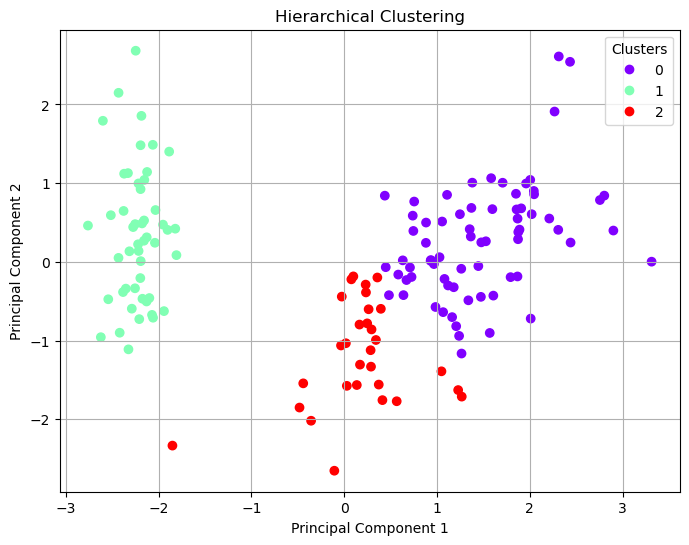

In [383]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3
)

hc_clusters = hc.fit_predict(x_scaled)

#Visualisation of hierarchical clusterin
plt.figure(figsize=(8,6))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=hc_clusters,
    cmap='rainbow'
)

plt.title("Hierarchical Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Create legend
legend1 = plt.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

plt.grid(True)
plt.show()

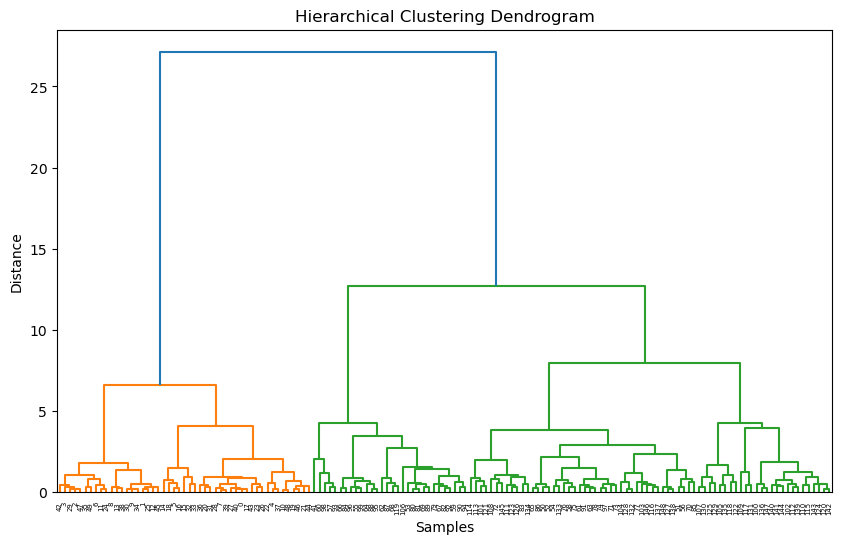

In [327]:
#Dendogram

#importing ddendogram library
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(x_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [ ]:
#report


Hierarchical clustering is suitable for the Iris dataset because it can reveal the natural 
relationships between flowers without requiring random centroid initialization. The dendrogram
provides a visual representation of how clusters are formed.as above mentioned, Due to overlapping feature values cannot be identified with 100% certainty for the legend therefore visualizing per clusters.

In [384]:
#conclusion

The objective of this assessment is to apply unsupervised machine learning techniques to the Iris dataset using K-Means Clustering and Hierarchical Clustering. The aim is to group similar flower samples based on their measurements without using the species labels and to visualize the resulting clusters.

Both K-Means and Hierarchical Clustering successfully identified meaningful groups within the Iris dataset. The clustering results indicate that the flowers naturally form three distinct groups based on their sepal and petal measurements.

K-Means efficiently partitioned the data into three clusters with low computational complexity, while Hierarchical Clustering provided additional insight into the relationships between samples through its hierarchical grouping process. The PCA visualizations further confirmed that the clusters are well separated, especially one cluster that is distinctly isolated from the others.

Overall, both clustering techniques proved effective for analyzing the Iris dataset and demonstrated the ability of unsupervised learning algorithms to discover hidden patterns without relying on predefined class labels.